In [1]:
#common imports and variables
import pickle
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import time

training_times = {}
labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC Score",
    "Matthews Corr (MCC)"
]

def model_performance_analysis(y_true, y_pred, y_probs, dataset_name):
    accuracy=accuracy_score(y_true, y_pred)
    precision=precision_score(y_true, y_pred)
    recall=recall_score(y_true, y_pred)
    f1=f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    mcc=matthews_corrcoef(y_true, y_pred)

    score_matrix = [accuracy, precision, recall, f1, auc, mcc]
    df_scores = pd.DataFrame({"Score": score_matrix}, index=labels)
    return df_scores

def printConfusionMatrices(y_train_true, y_train_pred, y_test_true, y_test_pred):
    class_labels = ["Edible", "Poisonous"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Training Confusion Matrix
    cm_train = confusion_matrix(y_train_true, y_train_pred)
    sns.heatmap(
        cm_train,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[0]
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title("Confusion Matrix (Training Data)")

    # Plot Test Confusion Matrix
    cm_test = confusion_matrix(y_test_true, y_test_pred)
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[1]
    )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title("Confusion Matrix (Test Data)")

    plt.tight_layout()
    plt.show()


Shape of training data: (6499, 23)
Shape of test data: (1625, 23)
Missing values in Training Data : 0
Missing values in Test Data : 0


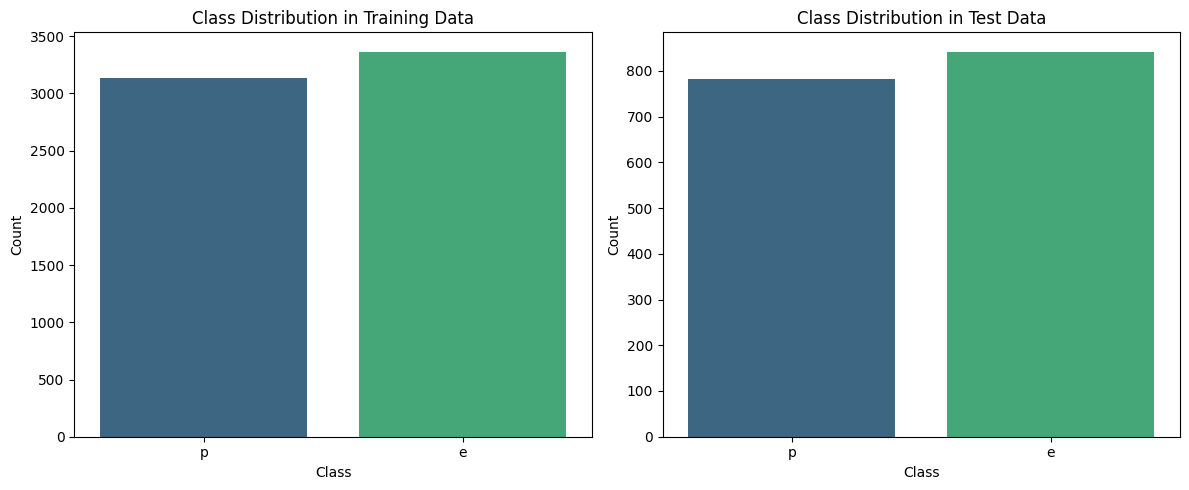

In [2]:
# https://www.kaggle.com/datasets/uciml/mushroom-classification
# Preparing data and EDA

import os
from sklearn.model_selection import train_test_split
# Create the 'trained_models' directory if it doesn't exist
os.makedirs('./trained_models', exist_ok=True)
df = pd.read_csv("mushrooms.csv")

train_data, test_data = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["class"]
)
test_data.to_csv("test_data.csv", index=False)
print(f"Shape of training data: {train_data.shape}")
print(f"Shape of test data: {test_data.shape}")
print(f"Missing values in Training Data :",train_data.isnull().sum().sum())
print(f"Missing values in Test Data :",test_data.isnull().sum().sum())

# Plot class distribution for training data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=train_data, x='class', hue='class', palette='viridis', legend=False)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')

# Plot class distribution for test data
plt.subplot(1, 2, 2)

sns.countplot(data=test_data, x='class', hue='class', palette='viridis', legend=False)
plt.title('Class Distribution in Test Data')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
## Encode and Scale data for the Logistic Regression , K-NN Algos and Naive Baye's

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

# Seperate the Input features and Output class of the Training data
X_train = train_data.drop("class", axis=1)
y_train = train_data["class"]

# Seperate the Input features and Output class of the Test data
X_test = test_data.drop("class", axis=1)
y_test = test_data["class"]

#Define the Encoders and the Scalers
oneHotEncoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
label_encoder = LabelEncoder()
scaler = StandardScaler()

#Encode the Input features of the Training data using OneHotEncoder
X_train_ohe = oneHotEncoder.fit_transform(X_train)
#Encode the Output class of the Training data using LabelEncoder
y_train_le = label_encoder.fit_transform(y_train)
#Scale the Input features of the Training data
X_train_ohe_scaled = scaler.fit_transform(X_train_ohe)


# Save the fitted encoder,label_encoder & scaler to a file for later prediction
with open('./trained_models/encoder.pkl', 'wb') as f:
    pickle.dump(oneHotEncoder, f)
with open('./trained_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
with open('./trained_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


#Encode the Input features of the Test data using OneHotEncoder
X_test_ohe = oneHotEncoder.transform(X_test)
#Scale the Input features of the Training data
X_test_ohe_scaled = scaler.transform(X_test_ohe)
#Encode the Output class of the Test data using LabelEncoder
y_test_le = label_encoder.transform(y_test)




Logistic Regression Score Comparison (Training vs. Test):


,Training Score,Test Score
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1-Score,1.0,1.0
AUC Score,1.0,1.0
Matthews Corr (MCC),1.0,1.0


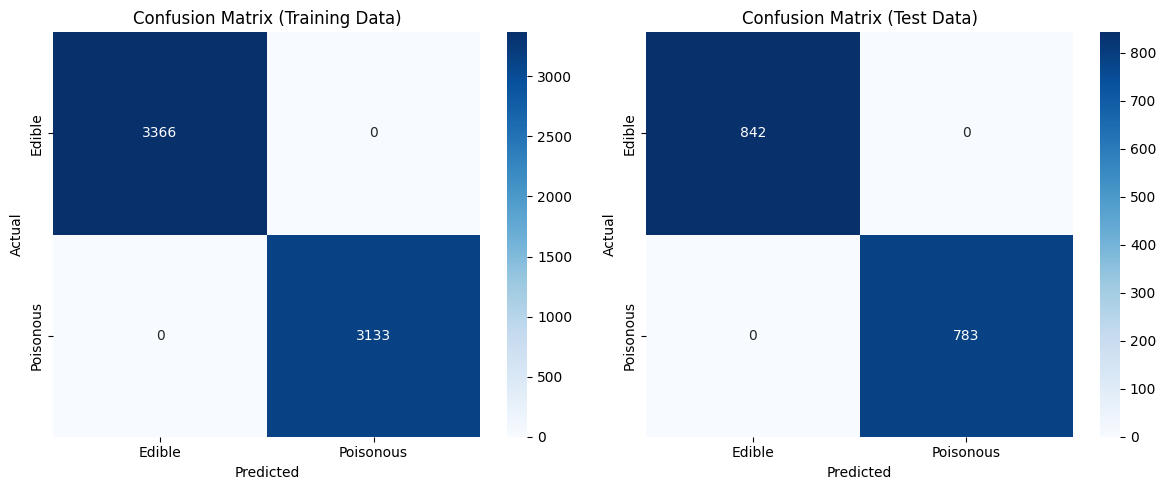

In [4]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=20)
start = time.time()
lr.fit(X_train_ohe_scaled, y_train_le)
training_times['Logistic Regression'] = time.time() - start

y_train_pred_lr = lr.predict(X_train_ohe_scaled)
y_test_pred_lr = lr.predict(X_test_ohe_scaled)

y_train_probs_lr = lr.predict_proba(X_train_ohe_scaled)[:, 1]
y_test_probs_lr = lr.predict_proba(X_test_ohe_scaled)[:, 1]

# Get training and test scores
train_scores_lr = model_performance_analysis(y_train_le, y_train_pred_lr, y_train_probs_lr, "Training")
test_scores_lr = model_performance_analysis(y_test_le, y_test_pred_lr, y_test_probs_lr, "Test")

# Combine and display scores side-by-side
combined_scores_lr = pd.concat(
    [train_scores_lr.rename(columns={'Score': 'Training Score'}),
     test_scores_lr.rename(columns={'Score': 'Test Score'})],
    axis=1
)
print("\nLogistic Regression Score Comparison (Training vs. Test):")
display(combined_scores_lr.round(5))

# Print confusion matrices side-by-side
printConfusionMatrices(y_train_le, y_train_pred_lr, y_test_le, y_test_pred_lr)

# Save the trained model as a pickle file
with open("./trained_models/logistic_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)


kNN Score Comparison (Training vs. Test):


,Training Score,Test Score
Accuracy,0.99969,0.99877
Precision,1.00000,1.00000
Recall,0.99936,0.99745
F1-Score,0.99968,0.99872
AUC Score,1.00000,1.00000
Matthews Corr (MCC),0.99938,0.99754


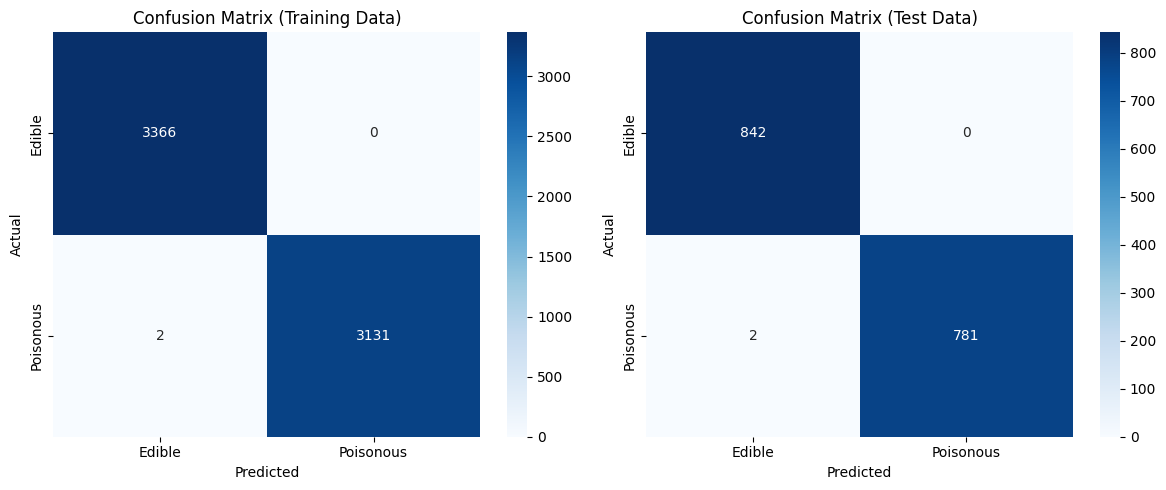

In [5]:
# kNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train_ohe_scaled, y_train_le)
training_times['kNN'] = time.time() - start

y_train_pred_knn = knn.predict(X_train_ohe_scaled)
y_test_pred_knn = knn.predict(X_test_ohe_scaled)

y_train_probs_knn = knn.predict_proba(X_train_ohe_scaled)[:, 1]
y_test_probs_knn = knn.predict_proba(X_test_ohe_scaled)[:, 1]

# Get training and test scores
train_scores_knn = model_performance_analysis(y_train_le, y_train_pred_knn, y_train_probs_knn, "Training")
test_scores_knn = model_performance_analysis(y_test_le, y_test_pred_knn, y_test_probs_knn, "Test")

# Combine and display scores side-by-side
combined_scores_knn = pd.concat(
    [train_scores_knn.rename(columns={'Score': 'Training Score'}),
     test_scores_knn.rename(columns={'Score': 'Test Score'})],
    axis=1
)
print("\nkNN Score Comparison (Training vs. Test):")
display(combined_scores_knn.round(5))

# Print confusion matrices side-by-side
printConfusionMatrices(y_train_le, y_train_pred_knn, y_test_le, y_test_pred_knn)

# Save the trained model as a pickle file
with open("./trained_models/knn_model.pkl", "wb") as file:
    pickle.dump(knn, file)

In [6]:
## Encode data for the Tree based algos (Decision Tree and Random Forest)
# Convert every Input feature from text strings to numeric categories instantly for Training Data
X_train_oe = train_data.drop('class', axis=1).apply(lambda x: x.astype('category').cat.codes)

# Convert every every Input feature from text strings to numeric categories instantly for Test Data
X_test_oe = test_data.drop('class', axis=1).apply(lambda x: x.astype('category').cat.codes)



Decision TreeScore Comparison (Training vs. Test):


,Training Score,Test Score
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1-Score,1.0,1.0
AUC Score,1.0,1.0
Matthews Corr (MCC),1.0,1.0


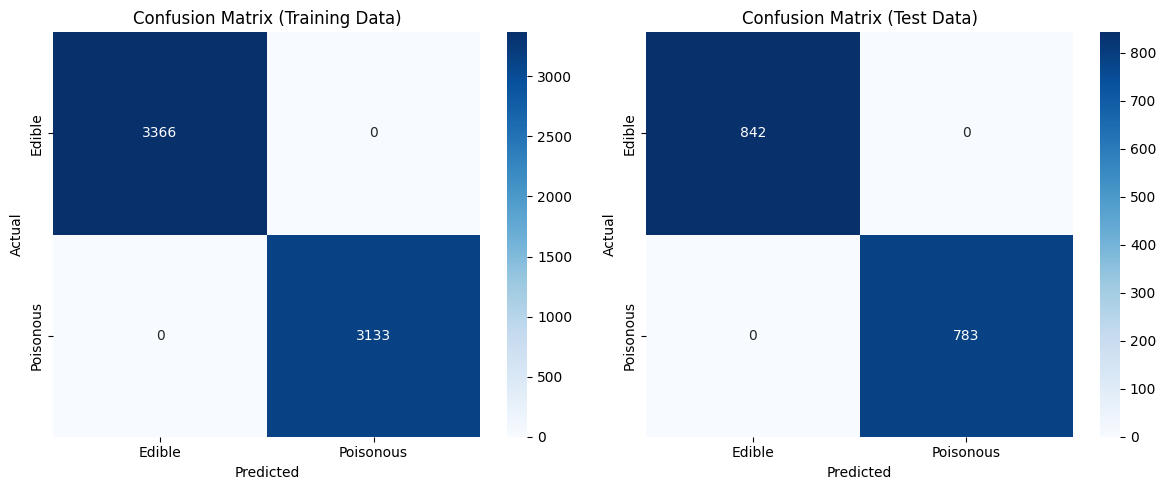

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(random_state=42)
start = time.time()
dt.fit(X_train_oe, y_train_le)
training_times['Decision Tree'] = time.time() - start

y_train_pred_dt = dt.predict(X_train_oe)
y_test_pred_dt = dt.predict(X_test_oe)

y_train_probs_dt = dt.predict_proba(X_train_oe)[:, 1]
y_test_probs_dt = dt.predict_proba(X_test_oe)[:, 1]

# Get training and test scores
train_scores_dt = model_performance_analysis(y_train_le, y_train_pred_dt, y_train_probs_dt, "Training")
test_scores_dt = model_performance_analysis(y_test_le, y_test_pred_dt, y_test_probs_dt, "Test")

# Combine and display scores side-by-side
combined_scores_dt = pd.concat(
    [train_scores_dt.rename(columns={'Score': 'Training Score'}),
     test_scores_dt.rename(columns={'Score': 'Test Score'})],
    axis=1
)
print("\nDecision Tree Score Comparison (Training vs. Test):")
display(combined_scores_dt.round(5))

# Print confusion matrices side-by-side
printConfusionMatrices(y_train_le, y_train_pred_dt, y_test_le, y_test_pred_dt)

# Save the trained model as a pickle file
with open("./trained_models/decision_tree_model.pkl", "wb") as file:
    pickle.dump(dt, file)


--- Naive Bayes Performance ---

Score Comparison (Training vs. Test):


,Training Score,Test Score
Accuracy,0.95445,0.94585
Precision,0.99511,0.99013
Recall,0.90999,0.89655
F1-Score,0.95065,0.94102
AUC Score,0.99788,0.99718
Matthews Corr (MCC),0.91165,0.89494


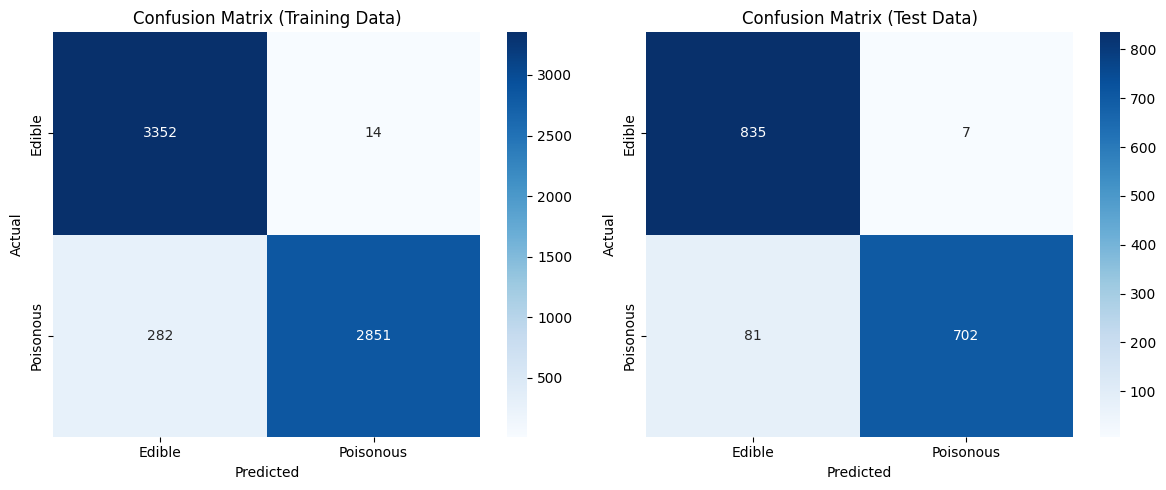

In [8]:
#Naive Bayes Classifier - Multinomial
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
start = time.time()
nb.fit(X_train_ohe, y_train_le)
training_times['Naive Bayes'] = time.time() - start

y_train_pred_nb = nb.predict(X_train_ohe)
y_test_pred_nb = nb.predict(X_test_ohe)

y_train_probs_nb = nb.predict_proba(X_train_ohe)[:, 1]
y_test_probs_nb = nb.predict_proba(X_test_ohe)[:, 1]

print("\n--- Naive Bayes Performance ---")

# Get training and test scores
train_scores_nb = model_performance_analysis(y_train_le, y_train_pred_nb, y_train_probs_nb, "Training")
test_scores_nb = model_performance_analysis(y_test_le, y_test_pred_nb, y_test_probs_nb, "Test")

# Combine and display scores side-by-side
combined_scores_nb = pd.concat(
    [train_scores_nb.rename(columns={'Score': 'Training Score'}),
     test_scores_nb.rename(columns={'Score': 'Test Score'})],
    axis=1
)
print("\nScore Comparison (Training vs. Test):")
display(combined_scores_nb.round(5))

# Print confusion matrices side-by-side
printConfusionMatrices(y_train_le, y_train_pred_nb, y_test_le, y_test_pred_nb)

# Save the trained model as a pickle file
with open("./trained_models/naive_bayes_model.pkl", "wb") as file:
    pickle.dump(nb, file)


--- Random Forest Performance ---

Score Comparison (Training vs. Test):


,Training Score,Test Score
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1-Score,1.0,1.0
AUC Score,1.0,1.0
Matthews Corr (MCC),1.0,1.0


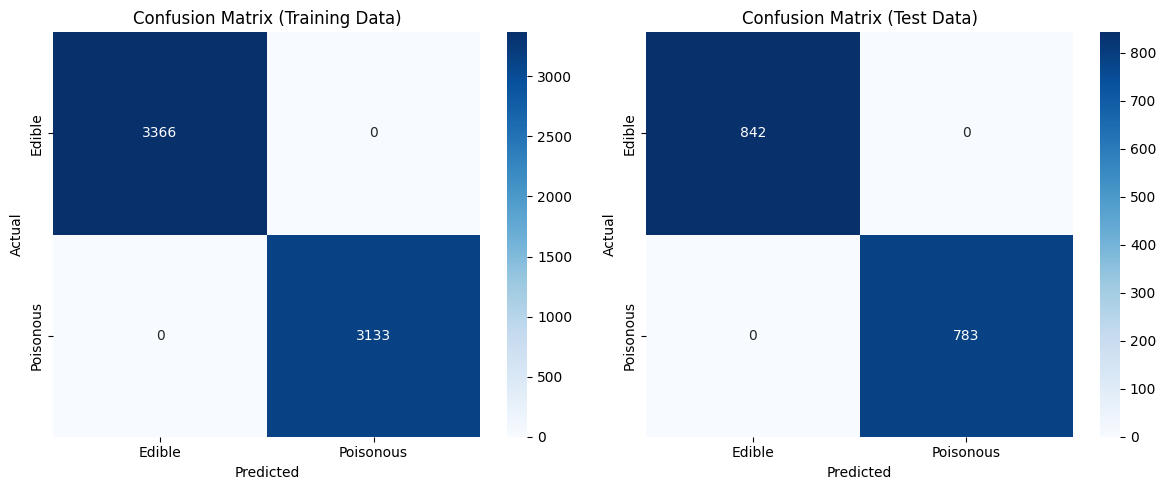

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
start = time.time()
rf.fit(X_train_oe, y_train_le)
training_times['Random Forest'] = time.time() - start

y_train_pred_rf = rf.predict(X_train_oe)
y_test_pred_rf = rf.predict(X_test_oe)

y_train_probs_rf = rf.predict_proba(X_train_oe)[:, 1]
y_test_probs_rf = rf.predict_proba(X_test_oe)[:, 1]

print("\n--- Random Forest Performance ---")

# Get training and test scores
train_scores_rf = model_performance_analysis(y_train_le, y_train_pred_rf, y_train_probs_rf, "Training")
test_scores_rf = model_performance_analysis(y_test_le, y_test_pred_rf, y_test_probs_rf, "Test")

# Combine and display scores side-by-side
combined_scores_rf = pd.concat(
    [train_scores_rf.rename(columns={'Score': 'Training Score'}),
     test_scores_rf.rename(columns={'Score': 'Test Score'})],
    axis=1
)
print("\nScore Comparison (Training vs. Test):")
display(combined_scores_rf.round(5))

# Print confusion matrices side-by-side
printConfusionMatrices(y_train_le, y_train_pred_rf, y_test_le, y_test_pred_rf)

# Save the trained model as a pickle file
with open("./trained_models/random_forest_model.pkl", "wb") as file:
    pickle.dump(rf, file)

In [10]:
print("Training Time Comparison:")
print("=" * 30)
for model, duration in training_times.items():
    print(f"{model:20}: {duration:.6f} seconds")

Training Time Comparison:
Logistic Regression : 0.204874 seconds
kNN                 : 0.000992 seconds
Decision Tree       : 0.004762 seconds
Naive Bayes         : 0.002032 seconds
Random Forest       : 0.097327 seconds


In [11]:
#Overfitting Check: Training vs. Test Performance
results = []

# Helper to calculate and store training vs test accuracy
def check_overfitting(name, model, X_train, y_train, X_test, y_test):
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 5),
        'Test Accuracy': round(test_acc, 5),
        'Gap': round(train_acc - test_acc, 5)
    })

# Check all models
check_overfitting('Logistic Regression', lr, X_train_ohe_scaled, y_train_le, X_test_ohe_scaled, y_test_le)
check_overfitting('K-NN', knn, X_train_ohe_scaled, y_train_le, X_test_ohe_scaled, y_test_le)
check_overfitting('Decision Tree', dt, X_train_oe, y_train_le, X_test_oe, y_test_le)
check_overfitting('Naive Bayes', nb, X_train_ohe, y_train_le, X_test_ohe, y_test_le)
check_overfitting('Random Forest', rf, X_train_oe, y_train_le, X_test_oe, y_test_le)

# Display comparison table
overfit_df = pd.DataFrame(results)
display(overfit_df)

,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,1.00000,1.00000,0.00000
1,K-NN,0.99969,0.99877,0.00092
2,Decision Tree,1.00000,1.00000,0.00000
3,Naive Bayes,0.95445,0.94585,0.00861
4,Random Forest,1.00000,1.00000,0.00000


In [12]:
import datetime
import platform

# Get the creation time of 'test_data.csv'
filepath = 'test_data.csv'
if os.path.exists(filepath):
    creation_timestamp = os.path.getctime(filepath)
    creation_datetime = datetime.datetime.fromtimestamp(os.path.getctime(filepath))
    print(f"\n--- Creation time for '{filepath}' ---")
    print(f"{filepath:30} Created: {creation_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

# List files in the 'trained_models' directory
print("\n--- Pickle Files saved of all 5 trained models along with encoders and scaler with their creation time---")
model_files = os.listdir('./trained_models')
for filename in model_files:
    filepath = os.path.join('./trained_models', filename)
    # Get the creation time (ctime) of the file
    creation_timestamp = os.path.getctime(filepath)
    creation_datetime = datetime.datetime.fromtimestamp(creation_timestamp)
    print(f"{filename:30} Created: {creation_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("\n--- System Information on which this notebook has been executed ---")
print(f"System: {platform.system()}")
print(f"Node Name: {platform.node()}")
print(f"Release: {platform.release()}")
print(f"Version: {platform.version()}")
print(f"Machine: {platform.machine()}")
print(f"Processor: {platform.processor()}")


print("\n--- Execution Date and Time ---")
print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



--- Creation time for 'test_data.csv' ---
test_data.csv                  Created: 2026-08-13 14:58:57

--- Pickle Files saved of all 5 trained models along with encoders and scaler with their creation time---
label_encoder.pkl              Created: 2026-08-13 14:58:58
logistic_regression_model.pkl  Created: 2026-08-13 14:58:58
knn_model.pkl                  Created: 2026-08-13 14:58:59
decision_tree_model.pkl        Created: 2026-08-13 14:58:59
naive_bayes_model.pkl          Created: 2026-08-13 14:58:59
random_forest_model.pkl        Created: 2026-08-13 14:58:59
encoder.pkl                    Created: 2026-08-13 14:58:58
scaler.pkl                     Created: 2026-08-13 14:58:58

--- System Information on which this notebook has been executed ---
System: Linux
Node Name: 6e8a7fcbe9ac
Release: 6.17.0-41-generic
Version: #41-Ubuntu SMP PREEMPT_DYNAMIC Sat Jun 20 18:01:40 UTC 2026
Machine: x86_64
Processor: x86_64

--- Execution Date and Time ---
2026-08-13 14:59:00
